# CP-divisibility: inverse, kernel, projector, fixed block, and SDP

Follow §§2, 6–7 of *Notes on the Pseudoinverse Reconstruction of Intermediate Quantum Maps*. At each earlier time $s$, set singular values strictly below the pointwise operator-norm radius $\epsilon_s$ to zero. If all four survive, use the direct inverse. Otherwise inspect kernel consistency, the CP range projector, and fixed Choi principal blocks, then use the CPTP SDP when the shortcuts cannot decide. The left panel retains the raw inverse eigenvalues for comparison; the right panel shows this **effective-rank analysis**.

Raw eigenvalue negativity is a property of the reconstructed matrices, not automatically a statistically significant experimental violation. The uncertainty estimates are pointwise and approximate. All singular-model conclusions are conditional on that model; setting small singular values to zero does not prove physical rank loss.

In [1]:
from pathlib import Path

import cvxpy as cp
import matplotlib.pyplot as plt
import numpy as np
from qiskit.quantum_info import Choi, Kraus, SuperOp

plt.rcParams.update({"font.family": "serif", "font.size": 12})

## Configuration

The absolute rank cutoff at time $s$ is $\epsilon_s$, estimated from the counts below: retain $\sigma_i\ge\epsilon_s$ and discard $\sigma_i<\epsilon_s$, also excluding numerical zeros. There is no separate inverse-ratio threshold. This is an explicit effective-rank model, not proof of exact physical rank loss or a guarantee of stable inversion near the cutoff. The same cutoff at each time is held fixed when checking bootstrap rank agreement. The raw-inverse panel still shows every numerically available eigenvalue.

`FIT_ATOL` is a numerical operator-norm tolerance. `PHYSICAL_TOL` checks numerical HP, CP and TP; experimental uncertainties do not silently relax the exact CP-projector theorem. For retained-rank inverses, HP/TP defects are reported separately and do not trigger SDP. Passing the inversion cutoff is not a guarantee of stable inversion near the cutoff. Kernel uncertainty is estimated by a fixed-rank bootstrap, with rank agreement checked separately. All figures use 300 dpi; only short summaries are printed.

In [2]:
DATA_PATH = Path("results/process_tomography/ibm_strasbourg/2025-05-10T11-34-55/init+/q[4, 3, 5, 15]-np50-gpp50-s8192.npz")
N_BOOT = 1000
CONFIDENCE = 0.95
SEED = 42
FIT_ATOL = 1e-5
PHYSICAL_TOL = 1e-6
SDP_SOLVER = "SCS"
SOLVER_EPS = 1e-8

## Count resampling and map uncertainty

The four prepared target states are $|0\rangle,|1\rangle,|+\rangle,|+i\rangle$; the measurement indices are $Z,X,Y$. We marginalize the target bit indicated by `tomography_clbits`, including the two-bit `q118` records. The Pauli-transfer reconstruction below is linear in the 12 measured expectations. Resampled **changes** in this linear reconstruction are added to the saved Choi-derived map. This retains the reported fit while approximating its shot noise. It reproduces the saved maps to floating-point precision except for the earliest three points of two `q4` runs, where the original constrained tomography fit differs. This approximation does not account for fit constraints, drift, SPAM, or correlated hardware errors; near those boundary fits the quoted uncertainty may be optimistic.

At each time $s$, use $\epsilon_s=Q_{0.95}[\|S_s^{(b)}-\widehat S_s\|_2]$, where the operator (spectral) norm is the largest singular value of the error matrix. The ratio $r_s=\epsilon_s/\sigma_{\min}(\widehat S_s)$ diagnoses inversion sensitivity: $r_s\ll1$ is preferable, while $r_s\ge1$ means the bound cannot exclude a singular map. Values just below one can still be highly sensitive. These are **pointwise**, approximate shot-noise radii, not simultaneous confidence bounds for the entire heatmap. They do not establish exact rank loss.

In [3]:
def choi_to_superop(choi):
    return np.asarray(SuperOp(Choi(np.asarray(choi))).data)


paulis = [np.eye(2), np.array([[0, 1], [1, 0]]),
          np.array([[0, -1j], [1j, 0]]), np.diag([1, -1])]
pauli_basis = np.column_stack([p.reshape(4, order="F") for p in paulis]) / np.sqrt(2)


def linear_superops(counts, basis_indices, bitstrings, clbits):
    # counts: (..., setting, outcome); the leading dimensions include bootstrap/time.
    signs = np.array([
        [1 if bits[-int(clbits[j, 0]) - 1] == "0" else -1 for bits in bitstrings]
        for j in range(len(basis_indices))
    ])
    expectations = np.einsum("...jk,jk->...j", counts, signs) / counts.sum(axis=-1)
    measured = np.empty((*expectations.shape[:-1], 4, 3))  # X, Y, Z
    for j, (prep, measurement) in enumerate(basis_indices):
        measured[..., prep, {0: 2, 1: 0, 2: 1}[int(measurement)]] = expectations[..., j]

    transfer = np.zeros((*expectations.shape[:-1], 4, 4))  # I, X, Y, Z
    transfer[..., 0, 0] = 1
    transfer[..., 1:, 0] = (measured[..., 0, :] + measured[..., 1, :]) / 2
    transfer[..., 1:, 3] = (measured[..., 0, :] - measured[..., 1, :]) / 2
    transfer[..., 1:, 1] = measured[..., 2, :] - transfer[..., 1:, 0]
    transfer[..., 1:, 2] = measured[..., 3, :] - transfer[..., 1:, 0]
    return pauli_basis @ transfer @ pauli_basis.conj().T


with np.load(DATA_PATH) as data:
    time_us = data["time_us"].copy()
    counts = data["raw_counts"].copy()
    basis_indices = data["basis_indices"].copy()
    bitstrings = data["count_bitstrings"].copy()
    clbits = data["tomography_clbits"].copy()
    maps = np.array([choi_to_superop(choi) for choi in data["choi"]])

assert counts.shape[:2] == (len(time_us), 12)
assert np.array_equal(np.sort(basis_indices, axis=0)[:, 0], np.repeat(np.arange(4), 3))
original_linear = linear_superops(counts, basis_indices, bitstrings, clbits)
fit_difference = np.linalg.norm(maps - original_linear, axis=(-2, -1))

rng = np.random.default_rng(SEED)
sampled_counts = np.empty((N_BOOT, *counts.shape), dtype=np.int64)
for t in range(len(time_us)):
    for setting in range(counts.shape[1]):
        shots = counts[t, setting].sum()
        sampled_counts[:, t, setting] = rng.multinomial(
            shots, counts[t, setting] / shots, size=N_BOOT
        )
bootstrap_maps = maps[None] + (
    linear_superops(sampled_counts, basis_indices, bitstrings, clbits)
    - original_linear[None]
)
deviations = np.linalg.norm(bootstrap_maps - maps[None], ord=2, axis=(-2, -1))
epsilon = np.quantile(deviations, CONFIDENCE, axis=0)  # One radius per time.
sigma_min = np.linalg.svd(maps, compute_uv=False)[:, -1]
sensitivity = np.divide(epsilon, sigma_min, out=np.full_like(epsilon, np.inf), where=sigma_min > 0)
rank_cutoffs = epsilon.copy()  # Time-dependent effective-rank thresholds.
print(DATA_PATH.relative_to(Path("results/process_tomography/ibm_strasbourg")))
print(f"Pointwise {CONFIDENCE:.0%} operator-norm radii / rank cutoffs: {epsilon.min():.4f}–{epsilon.max():.4f}")
print(f"Earlier times with sigma_min < epsilon_s: {(sigma_min[:-1] < epsilon[:-1]).sum()}/{len(time_us)-1}")
if np.max(fit_difference) > 1e-6:
    print(f"Linear estimator differs from saved fit at "
          f"{np.count_nonzero(fit_difference > 1e-6)} times "
          f"(largest difference {fit_difference.max():.4f}); "
          "treat their uncertainties cautiously.")

2025-05-10T11-34-55/init+/q[4, 3, 5, 15]-np50-gpp50-s8192.npz
Pointwise 95% operator-norm radii / rank cutoffs: 0.0424–0.0484
Earlier times with sigma_min < epsilon_s: 5/49
Linear estimator differs from saved fit at 3 times (largest difference 0.0528); treat their uncertainties cautiously.


## Singular-map witnesses and CPTP completion

For the earlier map $A_s$ truncated at $\epsilon_s$, let $P_s=A_s A_s^+$ be its **output range** projector and $K_s=I-A_s^+A_s$ its **input kernel** projector. The later map $S_t$ remains the saved reconstruction. The linear consistency residual is $\Delta_{t,s}=S_tK_s$. SVD truncation need not preserve CP or TP, so $A_s$ is a rank model, not automatically a physical channel.

For noisy data, bootstrap the input kernel at the selected rank and compute a pointwise radius $Q_{0.95}[\|S_t^{(b)}K_s^{(b)}-S_tK_s\|_2]$. A residual above this radius is a kernel obstruction **conditional on the selected rank model**. This shortcut is used only if the threshold-selected rank agrees in at least `CONFIDENCE` of the bootstrap samples. Otherwise the kernel is unresolved and the pair proceeds to SDP. This conditional bootstrap is not evidence that the physical map has an exact kernel.

When factorization is numerically consistent, there are two independent sufficient witnesses:

* **CP range projector:** if $P_s$ is CP, negativity of $\chi(S_tA_s^+)$ excludes CP extensions of the fitted model.
* **Fixed principal block:** enumerate principal blocks in the computational Choi basis and require $[\chi(B(I-P_s))]_{I,I}=0$ for every matrix-basis element $B$. Then this block is fixed for every linear completion; a negative eigenvalue excludes CP completion even when $P_s$ is not CP. No fixed block found is **not** an infeasibility verdict. This is a sufficient search in the stated basis, not a search over all rotated compressions or constraints imposed by TP.

Projector and block witnesses concern the fixed reconstructed/truncated model, not statistical certification of its rank or projector. A merely CP-compatible noisy projector does not activate the theorem. Approximate consistency alone is insufficient for these exact witnesses; such pairs go to SDP. A CP pseudoinverse also needs TP to be an accepted CPTP completion.

Only reduced-rank pairs reach the kernel and SDP checks. The SDP minimizes $\|S_V A_s-S_t\|_2$ over CPTP $V$, accepting a residual within $\epsilon_t+\sqrt{2}(\epsilon_s+\delta_s)+\mathrm{FIT\_ATOL}$, with $\delta_s=\|\widehat S_s-A_s\|_2$ including truncation error. This bound uses $\|S_V\|_2\leq\sqrt{2}$ for qubit CPTP maps. Green is an accepted fit, not proof of exact divisibility. The pointwise radii are not a joint 95% test of all pairs. Black separates no accepted fit from numerical solver failures in the summary.

In [4]:
def channel_diagnostics(superop):
    J = np.asarray(Choi(SuperOp(superop)).data)
    hermitian_error = np.linalg.norm(J - J.conj().T, "fro")
    minimum = float(np.linalg.eigvalsh((J + J.conj().T) / 2).min())
    partial_trace = np.array([
        [np.trace(J[2*i:2*i+2, 2*j:2*j+2]) for j in range(2)] for i in range(2)
    ])
    return minimum, hermitian_error, float(np.linalg.norm(partial_trace - np.eye(2), "fro"))


def rank_decomposition(S_s, cutoff):
    u, values, vh = np.linalg.svd(S_s)
    numerical_tol = max(S_s.shape) * np.finfo(float).eps * values[0]
    keep = (values >= cutoff) & (values > numerical_tol)
    A_s = (u[:, keep] * values[keep]) @ vh[keep]
    pinv = (vh[keep].conj().T / values[keep]) @ u[:, keep].conj().T
    projector_eig, projector_hp, _ = channel_diagnostics(A_s @ pinv)
    projector_cp = projector_hp <= PHYSICAL_TOL and projector_eig >= -PHYSICAL_TOL
    return A_s, pinv, int(keep.sum()), projector_cp


def cvx_superop_from_choi(choi):
    return cp.hstack([
        cp.reshape(choi[2*i:2*i+2, 2*j:2*j+2], (4, 1), order="F")
        for j in range(2) for i in range(2)
    ])


# One reusable qubit SDP, with Qiskit's Choi/SuperOp convention.
choi_variable = cp.Variable((4, 4), hermitian=True)
S_s_parameter = cp.Parameter((4, 4), complex=True)
S_t_parameter = cp.Parameter((4, 4), complex=True)
V = cvx_superop_from_choi(choi_variable)
partial_trace = cp.vstack([
    cp.hstack([cp.trace(choi_variable[2*i:2*i+2, 2*j:2*j+2]) for j in range(2)])
    for i in range(2)
])
problem = cp.Problem(cp.Minimize(cp.norm(V @ S_s_parameter - S_t_parameter, 2)),
                     [choi_variable >> 0, partial_trace == np.eye(2)])


def cptp_completion(S_s, S_t, fit_allowance=0.0):
    S_s_parameter.value, S_t_parameter.value = S_s, S_t
    try:
        options = {"eps": SOLVER_EPS, "max_iters": 20_000} if SDP_SOLVER == "SCS" else {}
        problem.solve(solver=SDP_SOLVER, warm_start=True, verbose=False, **options)
    except cp.error.SolverError:
        return False, np.nan, "solver error"
    if problem.status != cp.OPTIMAL or V.value is None:
        return False, np.nan, str(problem.status)
    minimum, hp, tp = channel_diagnostics(V.value)
    residual = float(np.linalg.norm(V.value @ S_s - S_t, ord=2))
    if minimum < -PHYSICAL_TOL or max(hp, tp) > PHYSICAL_TOL:
        return False, residual, "invalid completion"
    if residual > FIT_ATOL + fit_allowance:
        return False, residual, "residual above tolerance"
    return True, residual, "CPTP completion"


def choi_array(S):
    # Batch reshuffling in Qiskit's column-vectorization convention.
    shape = S.shape[:-2]
    return S.reshape(-1, 2, 2, 2, 2).transpose(0, 4, 2, 3, 1).reshape(*shape, 4, 4)


def fixed_principal_blocks(projector):
    from itertools import combinations
    Q = np.eye(4) - projector
    changes = choi_array(np.eye(16).reshape(16, 4, 4) @ Q)
    blocks = []
    for size in range(1, 5):
        for indices in combinations(range(4), size):
            # All 16 coefficients vanish: invariance for any complex B.
            if np.max(abs(changes[:, indices, :][:, :, indices])) <= 1e-9:
                blocks.append(indices)
    return blocks


def singular_witness(S_t, decomposition, blocks):
    A_s, pinv, rank, projector_cp = decomposition
    candidate = S_t @ pinv
    residual = np.linalg.norm(candidate @ A_s - S_t, ord=2)
    if residual > FIT_ATOL:
        return np.nan, ""  # Exact projector/block identities do not apply.
    minimum, hp, tp = channel_diagnostics(candidate)
    if hp > PHYSICAL_TOL:
        return np.nan, ""
    if projector_cp and (minimum < -PHYSICAL_TOL or tp <= PHYSICAL_TOL):
        return minimum, "projector"
    J = choi_array(candidate)
    for indices in blocks:
        block = J[np.ix_(indices, indices)]
        block_min = float(np.linalg.eigvalsh((block + block.conj().T) / 2).min())
        if block_min < -PHYSICAL_TOL:
            return block_min, "fixed block"
    return np.nan, ""

## Checks against the notes, then all measured pairs

The exact examples below exercise the unique inverse, kernel revival, CP-projector shortcut, the §5 false-positive pseudoinverse example (which must admit an SDP completion), and a fixed negative block with a non-CP projector. For experimental data, the arrays `raw_eigenvalues`, `routes`, `kernel_residuals`, `kernel_limits`, `sdp_residuals`, and `reasons` retain the results without large tables.

Inverse results with all singular values retained and exact singular-model eigenvalue witnesses are shown quantitatively. The arrays `inverse_hp_errors` and `inverse_tp_errors` retain the numerical defects of direct inverses; these do not alter routing. The Choi diagnostic uses its Hermitian part, so an HP defect above tolerance must be considered before interpreting its spectrum as a CP test. A nonnegative spectrum alone does not establish TP. The left panel keeps raw inverses; the right uses the time-dependent effective rank. Neither a retained inverse nor an accepted SDP fit is a simultaneous statistical conclusion about the whole dynamics.

In [5]:
# Exact examples: no shot-noise allowance is used for these checks.
I4 = np.eye(4, dtype=complex)
dephasing = pauli_basis @ np.diag([1, 0, 0, 1]) @ pauli_basis.conj().T
contracted = pauli_basis @ np.diag([1, 0, 0, 0.5]) @ pauli_basis.conj().T
counterexample = pauli_basis @ np.diag([1, 0.5, 0.5, 0]) @ pauli_basis.conj().T
block_example = pauli_basis @ np.diag([1, 0.5, 0, 0.5]) @ pauli_basis.conj().T
assert np.isclose(channel_diagnostics(I4)[0], 0)
assert np.allclose(choi_array(counterexample), Choi(SuperOp(counterexample)).data)
dc = rank_decomposition(contracted, 0)
value, route = singular_witness(dephasing, dc, fixed_principal_blocks(dc[0] @ dc[1]))
assert route == "projector" and np.isclose(value, -0.5)
dc = rank_decomposition(counterexample, 0)
assert not dc[3] and np.isclose(channel_diagnostics(counterexample @ dc[1])[0], -0.5)
assert singular_witness(counterexample, dc, fixed_principal_blocks(dc[0] @ dc[1]))[1] == ""
assert cptp_completion(counterexample, counterexample)[0]  # Identity completion exists.
dc = rank_decomposition(block_example, 0)
assert not dc[3]
value, route = singular_witness(dephasing, dc, fixed_principal_blocks(dc[0] @ dc[1]))
assert route == "fixed block" and np.isclose(value, -0.5)
assert not cptp_completion(block_example, dephasing)[0]
dc = rank_decomposition(dephasing, 0)
assert np.linalg.norm(I4 - I4 @ dc[1] @ dc[0], ord=2) > FIT_ATOL  # Kernel revival.
assert not cptp_completion(dephasing, I4)[0]

n = len(time_us)
raw_eigenvalues = np.full((n, n), np.nan)
eigenvalues = np.full((n, n), np.nan)
routes = np.full((n, n), "", dtype=object)
reasons = np.full((n, n), "", dtype=object)
sdp_residuals = np.full((n, n), np.nan)
inverse_hp_errors = np.full((n, n), np.nan)
inverse_tp_errors = np.full((n, n), np.nan)
kernel_residuals = np.full((n, n), np.nan)
kernel_limits = np.full((n, n), np.nan)
rank_agreement = np.ones(n)
decompositions = [rank_decomposition(S, cutoff) for S, cutoff in zip(maps, rank_cutoffs)]
truncation_error = np.array([np.linalg.norm(S - d[0], ord=2) for S, d in zip(maps, decompositions)])
fit_allowances = epsilon[None, :] + np.sqrt(2) * (epsilon + truncation_error)[:, None]

for s, decomposition in enumerate(decompositions):
    A_s, pinv, rank, projector_cp = decomposition
    raw_eigenvalues[s, s] = eigenvalues[s, s] = 0.0
    routes[s, s] = "identity"
    if np.linalg.matrix_rank(maps[s]) == 4:
        for t in range(s + 1, n):
            candidate = np.linalg.solve(maps[s].T, maps[t].T).T
            raw_eigenvalues[s, t] = channel_diagnostics(candidate)[0]

    if rank < 4:
        blocks = fixed_principal_blocks(A_s @ pinv)
        kernel = I4 - pinv @ A_s
        # Hold the selected rank fixed while bootstrapping the subspace.
        _, boot_sv, boot_vh = np.linalg.svd(bootstrap_maps[:, s])
        boot_kernel = boot_vh[:, rank:].conj().swapaxes(-2, -1) @ boot_vh[:, rank:]
        numerical_tol = 4 * np.finfo(float).eps * boot_sv[:, 0]
        boot_keep = (boot_sv >= rank_cutoffs[s]) & (boot_sv > numerical_tol[:, None])
        rank_agreement[s] = np.mean(boot_keep.sum(axis=1) == rank)

    for t in range(s + 1, n):
        if rank == 4:
            candidate = np.linalg.solve(maps[s].T, maps[t].T).T
            minimum, hp, tp = channel_diagnostics(candidate)
            eigenvalues[s, t], routes[s, t] = minimum, "inverse"
            inverse_hp_errors[s, t], inverse_tp_errors[s, t] = hp, tp
            continue  # HP/TP defects are diagnostics, not SDP routing criteria.
        elif rank < 4:
            delta = maps[t] @ kernel
            delta_boot = bootstrap_maps[:, t] @ boot_kernel
            kernel_residuals[s, t] = np.linalg.norm(delta, ord=2)
            kernel_limits[s, t] = FIT_ATOL + np.quantile(
                np.linalg.norm(delta_boot - delta, ord=2, axis=(-2, -1)), CONFIDENCE
            )
            if rank_agreement[s] >= CONFIDENCE:
                if kernel_residuals[s, t] > kernel_limits[s, t]:
                    routes[s, t], reasons[s, t] = "kernel", "kernel revival conditional on rank model"
                    continue
                minimum, witness = singular_witness(maps[t], decomposition, blocks)
                if witness:
                    eigenvalues[s, t], routes[s, t] = minimum, witness
                    continue
            # Unstable rank or no exact witness: do not infer a violation; use SDP.

        # Reduced-rank pairs use the earlier map truncated at its own epsilon_s.
        success, residual, reason = cptp_completion(A_s, maps[t], fit_allowances[s, t])
        sdp_residuals[s, t], reasons[s, t] = residual, reason
        routes[s, t] = "SDP" if success else "black"

from collections import Counter
print("Retained ranks:", dict(Counter(d[2] for d in decompositions)))
print("Pair routes:", dict(Counter(routes[np.triu_indices(n, 1)])))
for label, errors in [("HP", inverse_hp_errors), ("TP", inverse_tp_errors)]:
    if np.any(errors > PHYSICAL_TOL):
        print(f"Inverse {label} defects above {PHYSICAL_TOL:g}: "
              f"{np.count_nonzero(errors > PHYSICAL_TOL)} pairs, max {np.nanmax(errors):.4g}; eigenvalues retained.")
if np.any(routes == "black"):
    print("Black-cell reasons:", dict(Counter(reasons[routes == "black"])))
if np.any(rank_agreement < CONFIDENCE):
    print(f"Rank agreement below {CONFIDENCE:.0%}: {(rank_agreement < CONFIDENCE).sum()} times; singular shortcuts skipped.")

Retained ranks: {4: 45, 3: 4, 2: 1}
Pair routes: {'inverse': 1121, 'SDP': 18, 'black': 72, 'kernel': 14}
Inverse TP defects above 1e-06: 144 pairs, max 0.007725; eigenvalues retained.
Black-cell reasons: {'residual above tolerance': 72}
Rank agreement below 95%: 4 times; singular shortcuts skipped.


## $t,s$ figures: raw eigenvalues and protocol outcome

All eigenvalue heatmaps use `magma` with a linear color scale; zero is not forced to the midpoint. The left and right panels share the minimum and maximum finite eigenvalues across both panels, so identical colors represent identical values. The separate fitted-model plot uses its own minimum and maximum.

**Left:** raw inverse minimum Choi eigenvalues wherever the saved matrix is numerically invertible. Orange squares mark earlier maps whose effective rank is below four after truncation at $\epsilon_s$. Their raw inverse values remain visible for comparison.

**Right:** `magma` shading shows the minimum eigenvalue of the **tested Choi matrix or block**: direct inverse when all singular values pass the inversion cutoff, CP-projector/pseudoinverse shortcut (dots), or a fixed negative Choi block (triangles). HP/TP defects of direct inverses are reported separately, not used to replace their eigenvalues with SDP results. **Symbols on light-gray cells** distinguish categorical outcomes from eigenvalues, and occur only when the earlier map has reduced effective rank: green circle = CPTP SDP fit within allowance when no eigenvalue shortcut decided the pair; purple × = kernel obstruction conditional on rank model; black + = no accepted SDP fit or a numerical failure. White without a symbol = untested $t<s$. Neither panel proves continuous-time divisibility or supplies a simultaneous significance test.

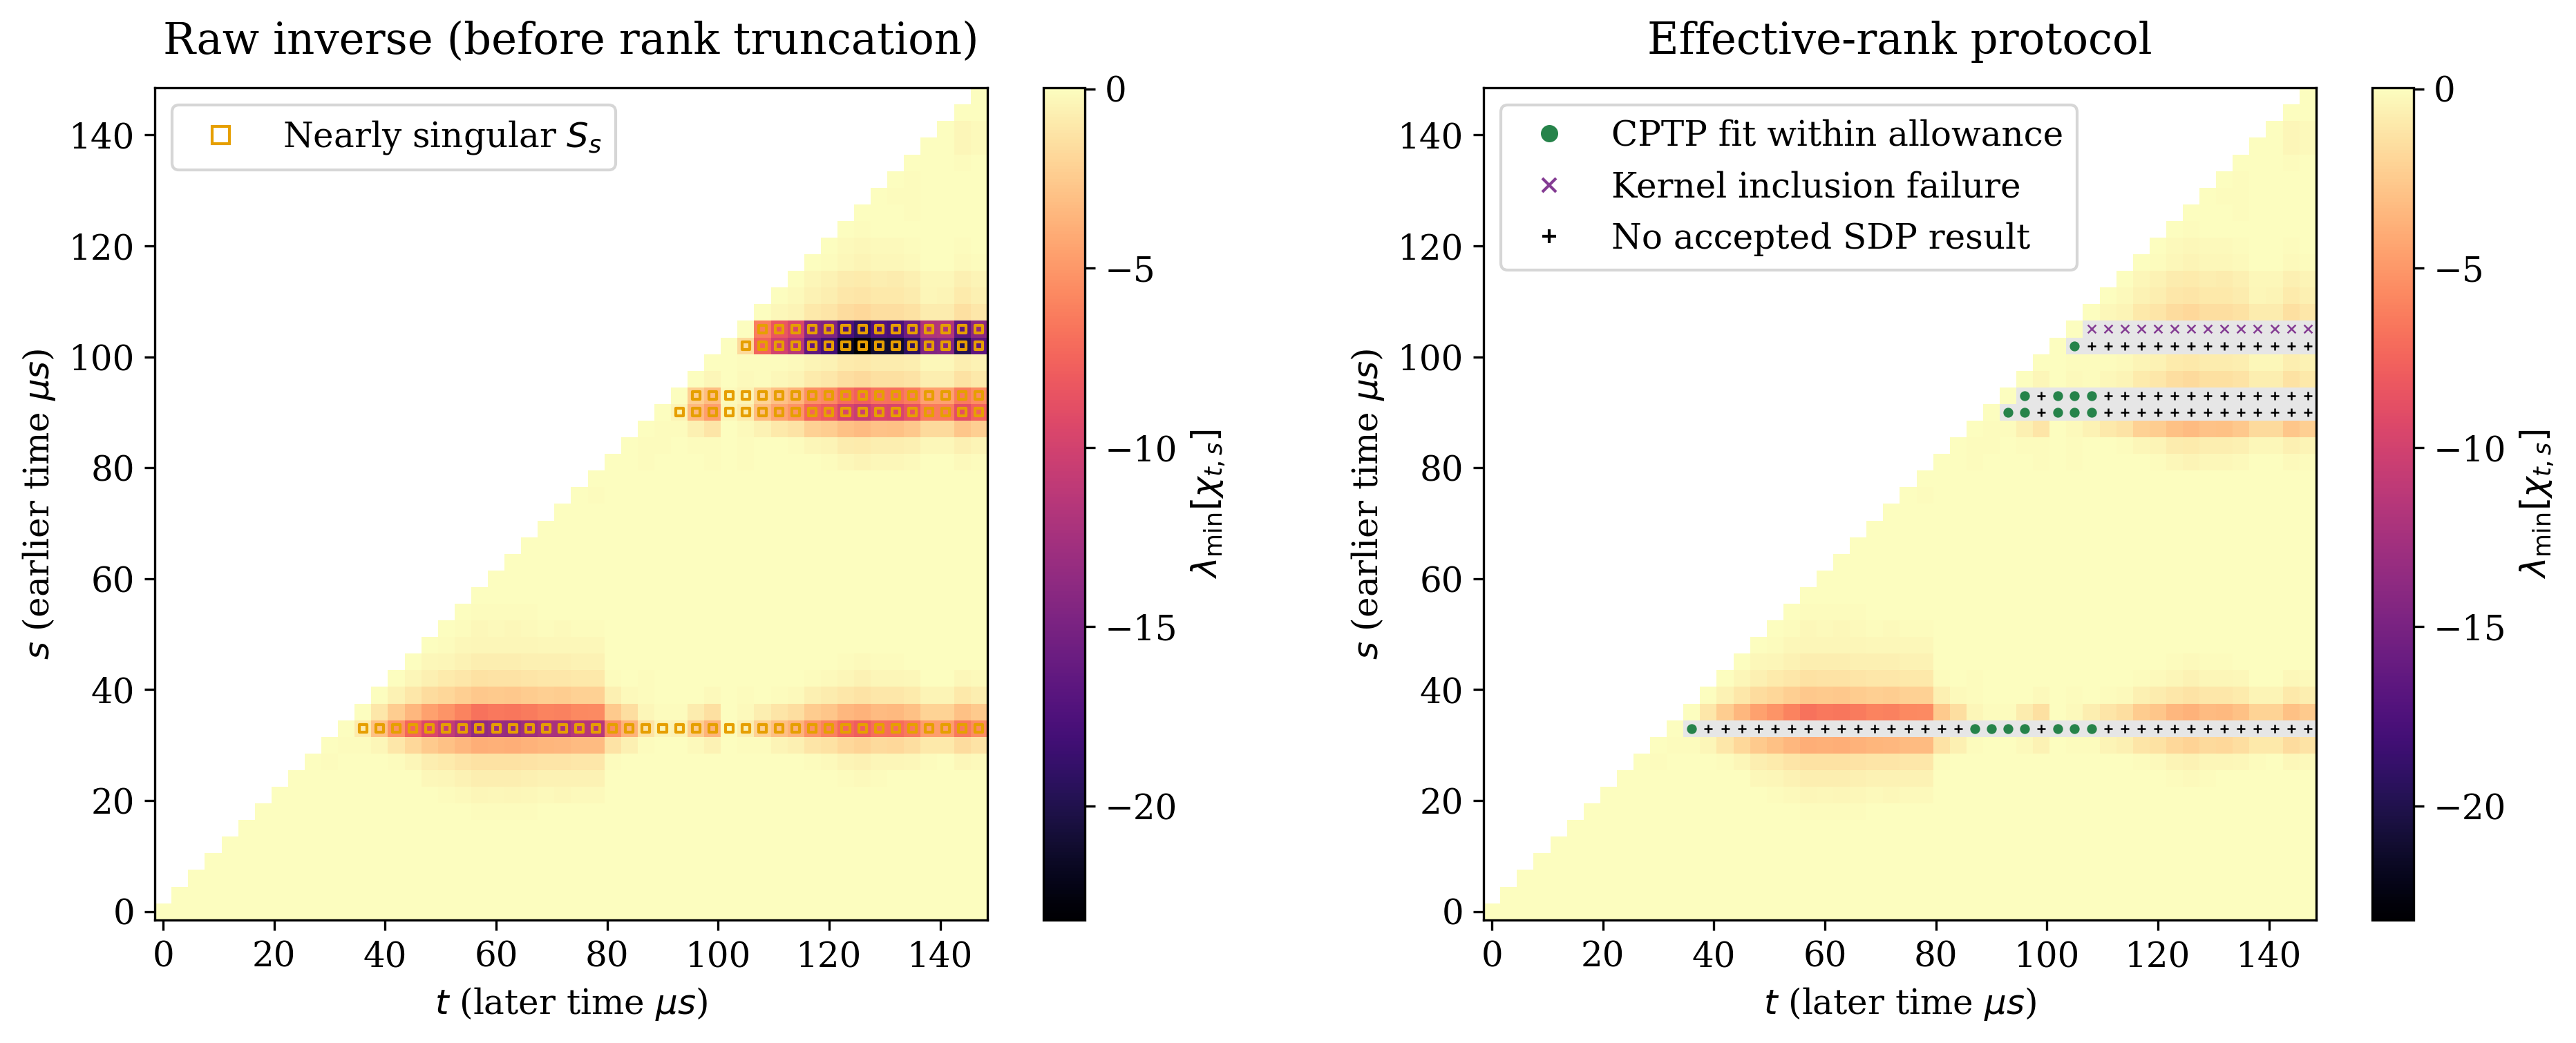

In [82]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=300)
edges = np.r_[time_us[0] - (time_us[1]-time_us[0])/2,
              (time_us[:-1] + time_us[1:])/2,
              time_us[-1] + (time_us[-1]-time_us[-2])/2]
cmap = plt.get_cmap("magma").copy()
cmap.set_bad((1, 1, 1, 0))
finite = np.concatenate([values[np.isfinite(values)] for values in [raw_eigenvalues, eigenvalues]])
shared_vmin, shared_vmax = finite.min(), finite.max()
for ax, values, title in zip(axes, [raw_eigenvalues, eigenvalues],
                            ["Raw inverse (before rank truncation)", "Effective-rank protocol"]):
    image = ax.pcolormesh(edges, edges, np.ma.masked_invalid(values), cmap=cmap,
                          vmin=shared_vmin, vmax=shared_vmax)
    fig.colorbar(image, ax=ax, label=r"$\lambda_{\min}[\chi_{t,s}]$", pad=0.05, shrink=1.0)
    ax.set(xlabel=r"$t$ (later time $\mu s$)", ylabel=r"$s$ (earlier time $\mu s$)", aspect="equal")
    ax.set_title(title, fontsize=15, y=1.02)

effective_ranks = np.array([d[2] for d in decompositions])
noisy = (effective_ranks[:, None] < 4) & np.isfinite(raw_eigenvalues)
np.fill_diagonal(noisy, False)
s_indices, t_indices = np.where(noisy)
if len(s_indices):
    axes[0].scatter(time_us[t_indices], time_us[s_indices], s=7, facecolors="none",
                    edgecolors="#e69f00", linewidths=1.0, marker="s")
    axes[0].legend(handles=[Line2D([], [], color="#e69f00", marker="s", markerfacecolor="none",
                                  linestyle="none", label=r"Nearly singular $S_s$")],
                   loc="upper left", fontsize=12)

categorical = np.isin(routes, ["SDP", "kernel", "black"])
axes[1].pcolormesh(edges, edges, np.ma.masked_where(~categorical, np.ones((n, n))),
                   cmap=ListedColormap(["#e6e6e6"]), vmin=0, vmax=1)
legend = []
for route, color, marker, label in [
    ("SDP", "#26834a", "o", "CPTP fit within allowance"),
    ("kernel", "#843c93", "x", "Kernel inclusion failure"),
    ("black", "black", "+", "No accepted SDP result"),
]:
    ss, tt = np.where(routes == route)
    if len(ss):
        axes[1].scatter(time_us[tt], time_us[ss], s=8, c=color,
                        marker=marker, linewidths=0.6)
        legend.append(Line2D([], [], color=color, marker=marker, markersize=5,
                             linestyle="none", label=label))
for route, marker, label in [("projector", ".", "CP-projector witness / completion"),
                              ("fixed block", "^", "Fixed negative Choi block")]:
    ss, tt = np.where(routes == route)
    if len(ss):
        axes[1].scatter(time_us[tt], time_us[ss], s=5, c="black", marker=marker)
        legend.append(Line2D([], [], color="black", marker=marker, linestyle="none", label=label))
if legend:
    axes[1].legend(handles=legend, loc="upper left", fontsize=12)
run = DATA_PATH.relative_to(Path("results/process_tomography/ibm_strasbourg"))
# fig.suptitle(f"{run.parts[0]} — {DATA_PATH.stem.split('-np')[0]}\n"
#              r"Effective-rank analysis: singular values below $\epsilon_s$ discarded", fontsize=11)
fig.tight_layout()
# plt.show()
plt.savefig("images/CP_div_4-3-5-15_robust.pdf", bbox_inches="tight", dpi=300)

## Fitted ZZ dynamics: explicit intermediate maps

Fit the same dataset's 12 raw-count Bloch expectations with the model from
`Process_tomography_bloch_visualize.ipynb`, using `src.zz_robustness` and 16
least-squares starts. Rates are nonnegative. The objective is unweighted, as in
that notebook; error bars show shot-noise standard errors, not fit uncertainty.
For a run without spectators use the no-ZZ model instead. Spectator parameters
are interchangeable fitted pairs, not identified physical qubits.

The model evolves $x(t)-iy(t)=\xi_2(t)[x_0-iy_0]$ and $z(t)=1+\eta(t)(z_0-1)$, where
$\eta(t)=e^{-\gamma_\downarrow t}$ and
$\xi_2(t)=e^{(-2\gamma_\phi-\gamma_\downarrow/2+i\omega_0)t}\prod_j\Phi_j(t)$.
Here $\Phi_j(t)=e^{-iJ_jt}[1+iJ_j(1-e^{-(\Gamma_j-2iJ_j)t})/(\Gamma_j-2iJ_j)]$,
evaluated with its continuous limit by the existing model code.

In Qiskit's column-vectorization convention,
$$S(t)=\begin{pmatrix}1&0&0&1-\eta(t)\\0&\xi_2(t)^*&0&0\\0&0&\xi_2(t)&0\\0&0&0&\eta(t)\end{pmatrix}.$$
If $\xi_2(s)\eta(s)\ne0$, its explicit inverse is
$$S(s)^{-1}=\begin{pmatrix}1&0&0&1-1/\eta(s)\\0&1/\xi_2(s)^*&0&0\\0&0&1/\xi_2(s)&0\\0&0&0&1/\eta(s)\end{pmatrix}.$$
Thus $V(t,s)=S(t)S(s)^{-1}$ has the same form with
$a=\eta(t)/\eta(s)$ and $b=\xi_2(t)/\xi_2(s)$. Its unnormalized Choi eigenvalues are
$$0,\quad 1-a,\quad \frac{1+a\pm\sqrt{(1-a)^2+4|b|^2}}{2}.$$
With nonnegative relaxation, CP is equivalent to $|b|^2\le a$.

The heatmap shows the actual fitted-model minimum eigenvalue on all sampled
$t\ge s$, without the tomography rank cutoff. Black denotes an undefined or
nonfinite inverse (including numerical underflow); it is not assigned an
eigenvalue. At an exact zero of $\xi_2(s)$, subsequent coherence revival violates
kernel inclusion. Near zeros, ratios can be very sensitive to fitted parameters.
These are **model-conditional results**, without parameter confidence bands or
a statistical significance claim. A fit overlay and residual summary show how
well this model describes the measured trajectories.

ZZ fit: 15/16 starts converged
Bloch RMSE: 0.04589; median shot-noise SE: 0.01101
Fitted parameters (µs⁻¹): {'gamma_phi0': np.float64(0.000295), 'Gamma_1': np.float64(0.026426), 'Gamma_2': np.float64(0.010903), 'Gamma_3': np.float64(0.000933), 'gamma_down0': np.float64(0.002449), 'J_1': np.float64(0.010702), 'J_2': np.float64(-0.013209), 'J_3': np.float64(0.048779), 'omega0': np.float64(-0.04063)}


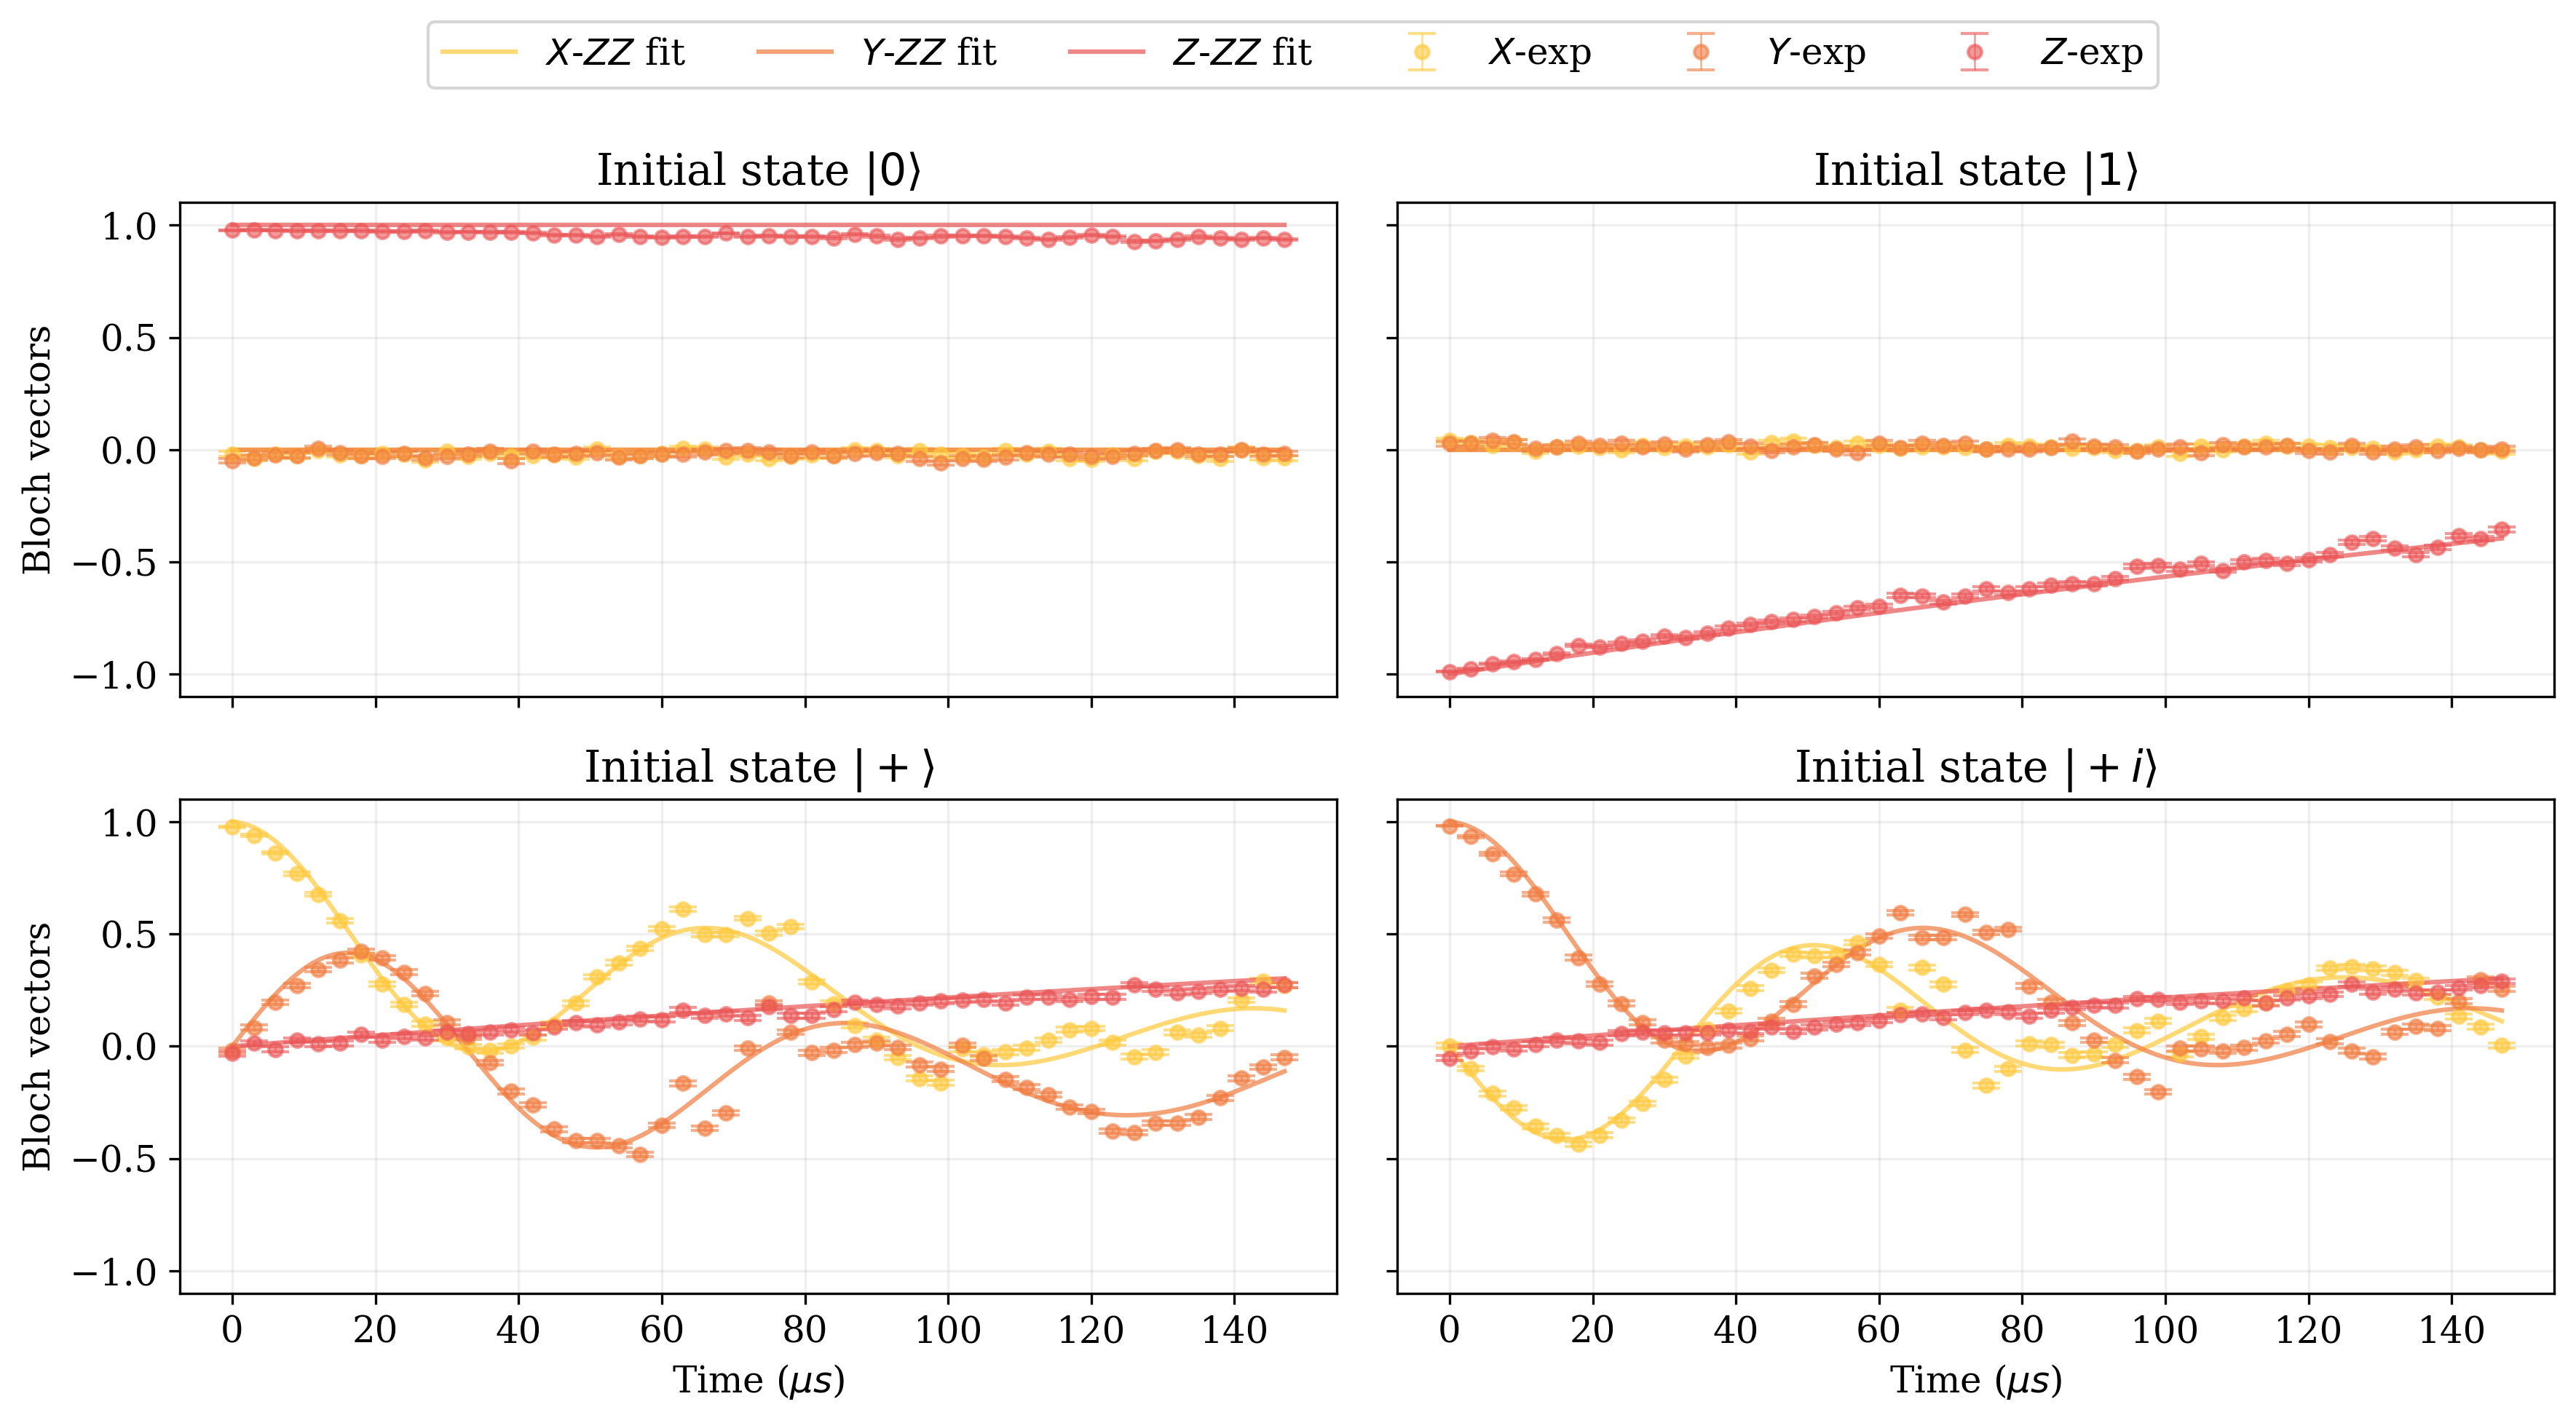

In [83]:
from scipy.optimize import least_squares
from src.zz_robustness import PARAMETERS, canonical, predict_jac, starting_points

ZZ_FIT_SEED = 230519
zz_model = "ZZ" if DATA_PATH.parent.name == "init+" else "GKLS"
zz_initial = np.array([[0., 0., 1.], [0., 0., -1.],
                       [1., 0., 0.], [0., 1., 0.]])
zz_prep = basis_indices[:, 0]
zz_axis = np.array([2, 0, 1])[basis_indices[:, 1]]
zz_signs = np.array([[1 if bits[-int(clbits[j, 0])-1] == "0" else -1
                      for bits in bitstrings] for j in range(len(basis_indices))])
zz_shots = counts.sum(axis=2)
zz_measured = np.einsum("tjk,jk->tj", counts, zz_signs) / zz_shots
zz_se = np.sqrt(np.maximum(0, 1 - zz_measured**2) / zz_shots)


def zz_residual_jac(theta):
    predictions = [predict_jac(theta, time_us, state, zz_model) for state in zz_initial]
    bloch = np.stack([p[0] for p in predictions])
    jacobian = np.stack([p[1] for p in predictions])
    residual = bloch[zz_prep, zz_axis].T - zz_measured
    jacobian = jacobian[zz_prep, zz_axis].transpose(1, 0, 2)
    return residual.ravel(), jacobian.reshape(-1, len(theta))


zz_n_rates, zz_n_params = (5, 9) if zz_model == "ZZ" else (2, 3)
zz_lower = np.r_[np.zeros(zz_n_rates), np.full(zz_n_params - zz_n_rates, -np.inf)]
zz_attempts = [least_squares(
    lambda theta: zz_residual_jac(theta)[0], start,
    jac=lambda theta: zz_residual_jac(theta)[1],
    bounds=(zz_lower, np.inf), x_scale="jac", max_nfev=1000,
) for start in starting_points(zz_model, count=16, seed=ZZ_FIT_SEED)]
zz_successful = [fit for fit in zz_attempts if fit.success]
if not zz_successful:
    raise RuntimeError("No model-fit start converged")
zz_fit = min(zz_successful, key=lambda fit: np.mean(fit.fun**2))
zz_theta = canonical(zz_fit.x) if zz_model == "ZZ" else zz_fit.x.copy()
zz_parameter_names = PARAMETERS if zz_model == "ZZ" else ["gamma_phi0", "gamma_down0", "omega0"]
print(f"{zz_model} fit: {len(zz_successful)}/16 starts converged")
print(f"Bloch RMSE: {np.sqrt(np.mean(zz_fit.fun**2)):.4g}; median shot-noise SE: {np.median(zz_se):.4g}")
print("Fitted parameters (µs⁻¹):", dict(zip(zz_parameter_names, np.round(zz_theta, 6))))

zz_plot_times = np.linspace(time_us[0], time_us[-1], 600)
zz_curves = np.stack([predict_jac(zz_theta, zz_plot_times, state, zz_model)[0]
                      for state in zz_initial])
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True, sharey=True, dpi=300)
for prep, (label, ax) in enumerate(zip(["0", "1", "+", "+i"], axes.flat)):
    for axis, (name, color) in enumerate(zip("XYZ", ["#ffc93c", "#f07b3f", "#ea5455"])):
        setting = np.flatnonzero((zz_prep == prep) & (zz_axis == axis)).item()
        ax.errorbar(time_us, zz_measured[:, setting], yerr=zz_se[:, setting], capsize=4.5,
                    marker="o", ls="", markersize=4.5, elinewidth=0.6, color=color, label=rf"${name}$-exp", alpha=0.6)
        ax.plot(zz_plot_times, zz_curves[prep, axis], color=color, label=rf"${name}$-$ZZ$ fit", alpha=0.7, lw=1.5)
    ax.set(title=rf"Initial state $|{label}\rangle$", xlabel=r"Time ($\mu s$)",
           ylabel="Bloch vectors", ylim=(-1.1, 1.1))
    ax.label_outer()
    ax.grid(alpha=0.2)
fig.legend(*axes.flat[0].get_legend_handles_labels(), loc="upper center",
           bbox_to_anchor=(0.5, 0.94), ncol=6, fontsize=12)
# fig.suptitle(f"{DATA_PATH.stem.split('-np')[0]} — {zz_model} fit to raw counts")
fig.tight_layout(rect=(0, 0, 1, 0.87))
# plt.show()
plt.savefig("images/ZZ_4-3-5-15_fit.pdf", bbox_inches="tight", dpi=300)

Model minimum Choi eigenvalue: -20.9647
Model-negative pairs (< -1e-10 numerical reporting tolerance): 401/1225; plotted values are not thresholded.
Undefined/nonfinite inverse pairs (t>s): 0


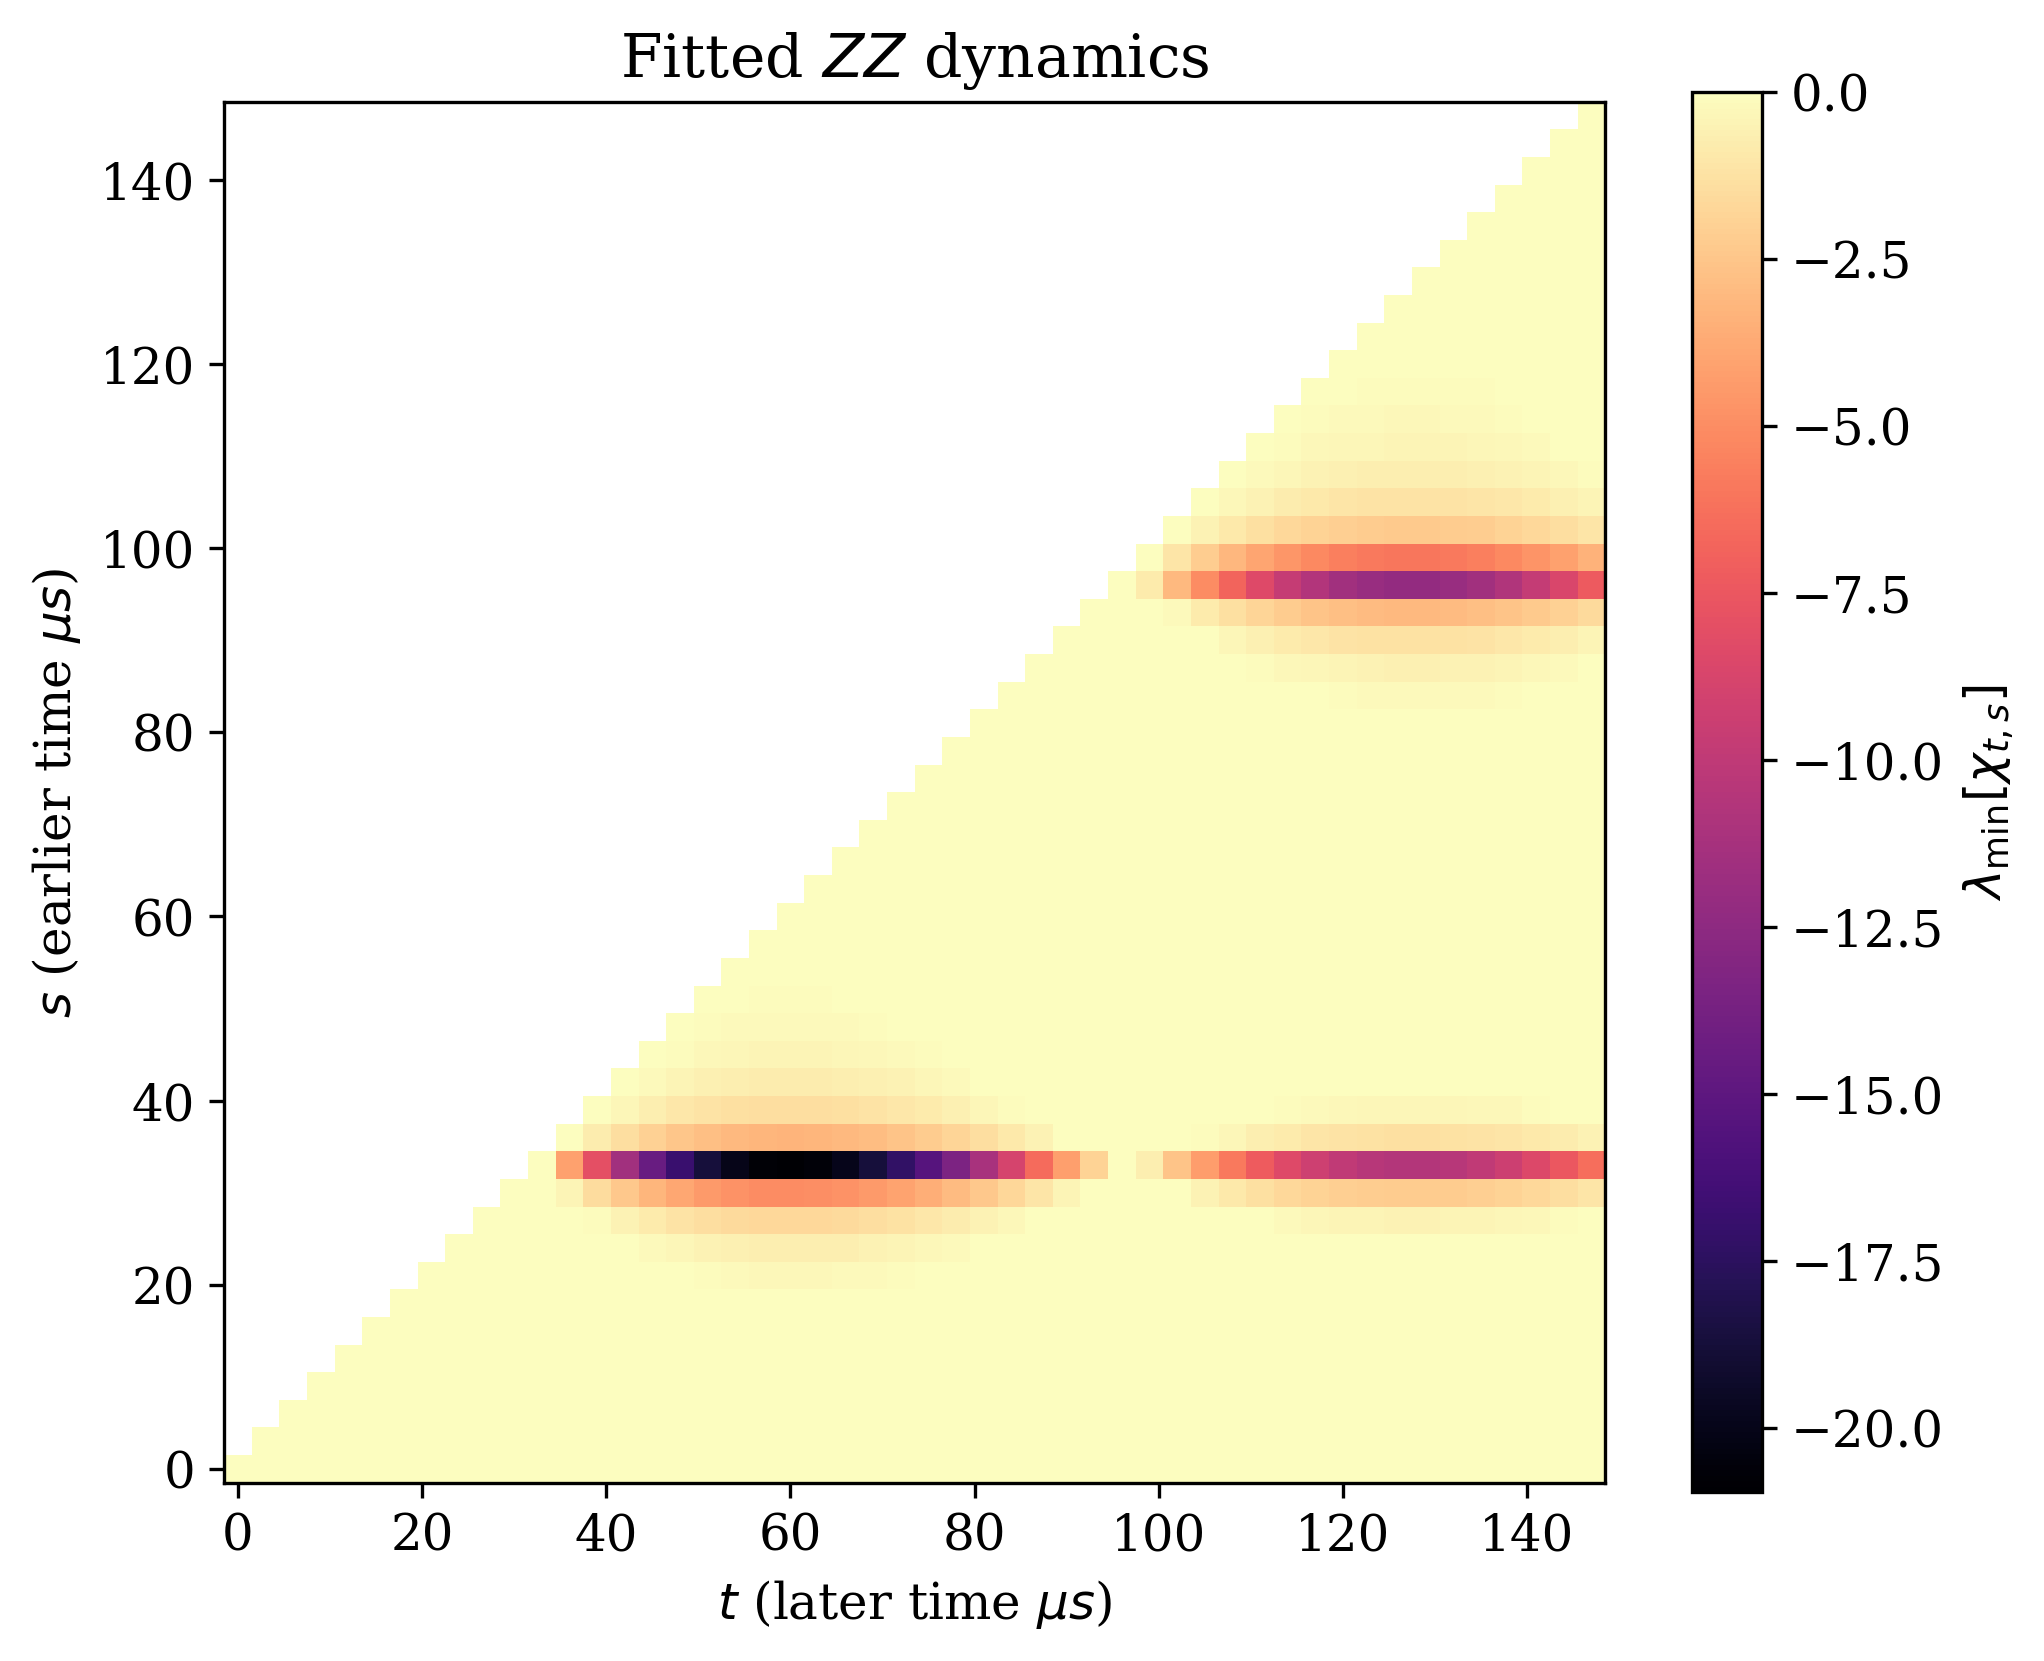

In [84]:
def zz_superop(eta, coherence):
    return np.array([[1, 0, 0, 1-eta], [0, coherence.conjugate(), 0, 0],
                     [0, 0, coherence, 0], [0, 0, 0, eta]], dtype=complex)


def zz_choi_eigenvalues(a, b):
    root = np.hypot(1-a, 2*abs(b))
    # Rationalized minus root avoids subtracting nearly equal numbers.
    minus = 2*(a-abs(b)**2) / (1+a+root)
    return np.sort([0., 1-a, minus, (1+a+root)/2])


zz_down = zz_theta[4] if zz_model == "ZZ" else zz_theta[1]
zz_eta = np.exp(-zz_down * time_us)
zz_equator = predict_jac(zz_theta, time_us, [1., 0., 0.], zz_model)[0]
zz_g = zz_equator[0] - 1j*zz_equator[1]
zz_maps = np.array([zz_superop(eta, g) for eta, g in zip(zz_eta, zz_g)])
zz_spectra = np.full((len(time_us), len(time_us), 4), np.nan)
zz_undefined = np.zeros((len(time_us), len(time_us)), dtype=bool)
for s in range(len(time_us)):
    for t in range(s, len(time_us)):
        if zz_g[s] == 0 or zz_eta[s] == 0:
            zz_undefined[s, t] = True
            continue
        a = np.exp(-zz_down * (time_us[t] - time_us[s]))
        with np.errstate(over="ignore", invalid="ignore", divide="ignore"):
            b = zz_g[t] / zz_g[s]
            spectrum = zz_choi_eigenvalues(a, b)
        if np.all(np.isfinite(spectrum)):
            zz_spectra[s, t] = spectrum
        else:
            zz_undefined[s, t] = True
zz_min_eigenvalues = zz_spectra[:, :, 0]

# Check the analytic inverse/spectrum against Qiskit at representative pairs.
zz_pairs = np.argwhere(np.isfinite(zz_min_eigenvalues) & np.triu(np.ones((n, n), bool), 1))
if len(zz_pairs):
    for s, t in zz_pairs[np.linspace(0, len(zz_pairs)-1, min(5, len(zz_pairs)), dtype=int)]:
        a = np.exp(-zz_down * (time_us[t] - time_us[s]))
        intermediate = zz_superop(a, zz_g[t]/zz_g[s])
        np.testing.assert_allclose(intermediate @ zz_maps[s], zz_maps[t], atol=1e-10)
        direct = np.linalg.solve(zz_maps[s].T, zz_maps[t].T).T
        np.testing.assert_allclose(intermediate, direct, rtol=1e-8, atol=1e-10)
        numeric = np.linalg.eigvalsh(Choi(SuperOp(intermediate)).data)
        np.testing.assert_allclose(zz_spectra[s, t], numeric, rtol=1e-8, atol=1e-10)
    zz_pair_minima = zz_min_eigenvalues[zz_pairs[:, 0], zz_pairs[:, 1]]
    print(f"Model minimum Choi eigenvalue: {zz_pair_minima.min():.6g}")
    print(f"Model-negative pairs (< -1e-10 numerical reporting tolerance): "
          f"{np.count_nonzero(zz_pair_minima < -1e-10)}/{len(zz_pairs)}; plotted values are not thresholded.")
print(f"Undefined/nonfinite inverse pairs (t>s): {np.count_nonzero(np.triu(zz_undefined, 1))}")

fig, ax = plt.subplots(figsize=(7, 6), dpi=300)
zz_finite = zz_min_eigenvalues[np.isfinite(zz_min_eigenvalues)]
image = ax.pcolormesh(edges, edges, np.ma.masked_invalid(zz_min_eigenvalues), cmap=cmap,
                     vmin=zz_finite.min() if zz_finite.size else 0.,
                     vmax=zz_finite.max() if zz_finite.size else 1.)
if np.any(zz_undefined):
    ax.pcolormesh(edges, edges, np.ma.masked_where(~zz_undefined, np.ones((n, n))),
                  cmap=ListedColormap(["black"]))
    ax.legend(handles=[Patch(facecolor="black", label="Undefined/nonfinite inverse")], loc="upper left")
fig.colorbar(image, ax=ax, label=r"$\lambda_{\min}[\chi_{t,s}]$", shrink=0.90)
ax.set(xlabel=r"$t$ (later time $\mu s$)", ylabel=r"$s$ (earlier time $\mu s$)", aspect="equal",
       title=r"Fitted $ZZ$ dynamics")
fig.tight_layout()
# plt.show()
plt.savefig("images/CP_div_4-3-5-15_ZZ_fit.pdf", bbox_inches="tight", dpi=300)